In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('C:\\Users\\DELL\\Documents\\Python\\CSV\\Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(columns = ['RowNumber', 'Surname', 'CustomerId'], inplace = True)

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df['Geography'].value_counts()

France     5014
Germany    2509
Spain      2477
Name: Geography, dtype: int64

In [7]:
df['Gender'].value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

In [8]:
df = pd.get_dummies(df, columns = ['Geography','Gender'], drop_first = True)

In [9]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,0,1,0


In [10]:
X = df.drop(columns=['Exited'])
y = df['Exited'].values

In [11]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_trf = scaler.fit_transform(X_train)
X_test_trf = scaler.transform(X_test)

In [13]:
import tensorflow

In [14]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [20]:
model = Sequential()

model.add(Dense(10,activation='sigmoid', input_dim=11))
model.add(Dense(1,activation='sigmoid'))

In [21]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 10)                120       
                                                                 
 dense_4 (Dense)             (None, 1)                 11        
                                                                 
Total params: 131 (524.00 Byte)
Trainable params: 131 (524.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [22]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam')

In [23]:
model.fit(X_train,y_train,epochs=10)

Epoch 1/10

250/250 [==============================] - 3s 6ms/step - loss: 0.7093
Epoch 2/10
250/250 [==============================] - 2s 7ms/step - loss: 0.5159
Epoch 3/10
250/250 [==============================] - 2s 6ms/step - loss: 0.5003
Epoch 4/10
250/250 [==============================] - 1s 5ms/step - loss: 0.4991
Epoch 5/10
250/250 [==============================] - 1s 3ms/step - loss: 0.4988
Epoch 6/10
250/250 [==============================] - 1s 3ms/step - loss: 0.4988
Epoch 7/10
250/250 [==============================] - 1s 4ms/step - loss: 0.4987
Epoch 8/10
250/250 [==============================] - 1s 4ms/step - loss: 0.4987
Epoch 9/10
250/250 [==============================] - 1s 4ms/step - loss: 0.4987
Epoch 10/10
250/250 [==============================] - 1s 4ms/step - loss: 0.4986


In [24]:
model.layers[0].get_weights()

[array([[-0.5283008 , -0.4360196 ,  0.44605875, -0.17947936,  0.08654433,
         -0.01422334, -0.23840466,  0.48620933,  0.41993973,  0.2818056 ],
        [ 0.49819505,  0.4061996 ,  0.02530838, -0.02169448,  0.4384868 ,
          0.37099504,  0.19927424, -0.51620513,  0.16656455,  0.16379918],
        [ 0.43728405,  0.19024606, -0.10863734,  0.4985482 ,  0.4291411 ,
         -0.40783787,  0.44402224, -0.34073338,  0.01525383,  0.28188476],
        [ 0.24519295, -0.51878107, -0.5177147 , -0.2869329 ,  0.53072244,
          0.26434886, -0.10481924,  0.34757054, -0.46665984,  0.28445664],
        [ 0.22482881,  0.3090007 , -0.4968242 ,  0.24585652,  0.20296514,
          0.04344457,  0.33600128,  0.48731095, -0.3058798 ,  0.38742808],
        [-0.1671636 , -0.23560633, -0.03690621,  0.26073974, -0.41562533,
         -0.22189727,  0.33453795, -0.03139091,  0.04134624,  0.02695424],
        [ 0.41453895, -0.6350575 , -0.14451465,  0.04258603, -0.4911053 ,
         -0.20862836,  0.2439615

In [27]:
y_log = model.predict(X_test_trf)

63/63 [==============================] - 0s 3ms/step


In [33]:
y_pred = np.where(y_log > 0.5,1,1)

In [34]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy_score(y_test,y_pred)

0.2025

In [40]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=11))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [41]:
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 10)                120       
                                                                 
 dense_12 (Dense)            (None, 10)                110       
                                                                 
 dense_13 (Dense)            (None, 1)                 11        
                                                                 
Total params: 241 (964.00 Byte)
Trainable params: 241 (964.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [42]:
model.compile(loss = 'binary_crossentropy', optimizer = 'Adam', metrics = ['accuracy'])

In [48]:
history = model.fit(X_train,y_train,epochs = 100, validation_split = 0.2)

Epoch 1/100
200/200 [==============================] - 2s 8ms/step - loss: 33.4185 - accuracy: 0.7011 - val_loss: 29.1329 - val_accuracy: 0.7856
Epoch 2/100
200/200 [==============================] - 1s 6ms/step - loss: 38.8268 - accuracy: 0.7013 - val_loss: 16.3467 - val_accuracy: 0.6037
Epoch 3/100
200/200 [==============================] - 1s 6ms/step - loss: 27.7253 - accuracy: 0.6950 - val_loss: 21.8066 - val_accuracy: 0.7706
Epoch 4/100
200/200 [==============================] - 1s 7ms/step - loss: 32.5308 - accuracy: 0.6948 - val_loss: 9.0899 - val_accuracy: 0.7775
Epoch 5/100
200/200 [==============================] - 2s 8ms/step - loss: 31.1418 - accuracy: 0.7008 - val_loss: 26.0426 - val_accuracy: 0.7337
Epoch 6/100
200/200 [==============================] - 2s 8ms/step - loss: 28.6149 - accuracy: 0.6995 - val_loss: 8.1431 - val_accuracy: 0.7713
Epoch 7/100
200/200 [==============================] - 1s 7ms/step - loss: 31.2421 - accuracy: 0.7003 - val_loss: 27.4811 - val_accu

200/200 [==============================] - 2s 8ms/step - loss: 19.4398 - accuracy: 0.7086 - val_loss: 22.2025 - val_accuracy: 0.6600
Epoch 58/100
200/200 [==============================] - 1s 6ms/step - loss: 26.6614 - accuracy: 0.6966 - val_loss: 14.9680 - val_accuracy: 0.7975
Epoch 59/100
200/200 [==============================] - 1s 5ms/step - loss: 24.2275 - accuracy: 0.7055 - val_loss: 36.1713 - val_accuracy: 0.3381
Epoch 60/100
200/200 [==============================] - 1s 5ms/step - loss: 23.3815 - accuracy: 0.7075 - val_loss: 10.1525 - val_accuracy: 0.7900
Epoch 61/100
200/200 [==============================] - 2s 8ms/step - loss: 18.9130 - accuracy: 0.7063 - val_loss: 18.4416 - val_accuracy: 0.7944
Epoch 62/100
200/200 [==============================] - 2s 8ms/step - loss: 26.0195 - accuracy: 0.7134 - val_loss: 12.8178 - val_accuracy: 0.7750
Epoch 63/100
200/200 [==============================] - 1s 7ms/step - loss: 32.2159 - accuracy: 0.6953 - val_loss: 51.3882 - val_accuracy

val_accuracy is more than the model accuracy that mean that model is overfit

In [46]:
y_log = model.predict(X_test_trf)

y_pred = np.where(y_log > 0.5,1,1)

63/63 [==============================] - 0s 3ms/step


In [47]:
accuracy_score(y_test,y_pred)

0.2025

In [49]:
import matplotlib.pyplot as plt

In [51]:
history.history

{'loss': [33.418548583984375,
  38.82675552368164,
  27.725332260131836,
  32.53079605102539,
  31.141830444335938,
  28.6148624420166,
  31.242088317871094,
  33.82489013671875,
  38.908729553222656,
  23.515239715576172,
  26.715970993041992,
  19.20200538635254,
  23.8067684173584,
  29.33885955810547,
  20.566675186157227,
  21.248252868652344,
  21.69207000732422,
  25.121723175048828,
  27.60135269165039,
  23.537063598632812,
  21.456008911132812,
  27.7338809967041,
  28.843799591064453,
  33.022125244140625,
  38.695579528808594,
  19.659875869750977,
  27.413270950317383,
  23.858552932739258,
  30.897890090942383,
  25.874561309814453,
  20.30803680419922,
  26.79751968383789,
  32.29828643798828,
  17.9499454498291,
  20.81460189819336,
  23.95746421813965,
  22.22201919555664,
  30.594057083129883,
  28.294605255126953,
  26.245952606201172,
  16.295473098754883,
  22.810029983520508,
  20.1012020111084,
  30.901090621948242,
  31.457334518432617,
  18.721662521362305,
  5

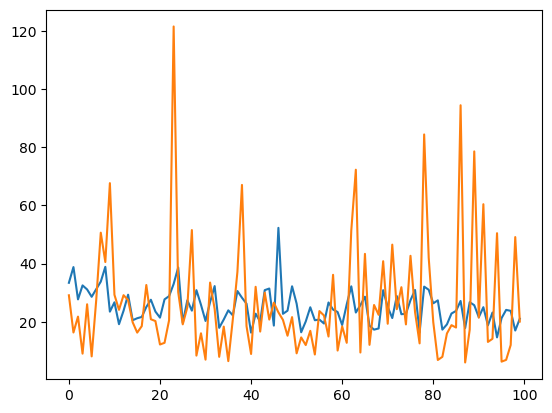

In [50]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

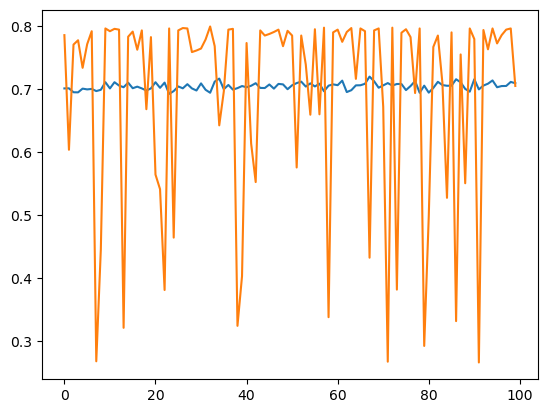

In [52]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [53]:
model = Sequential()

model.add(Dense(11,activation='sigmoid',input_dim=11))
model.add(Dense(11,activation='sigmoid'))
model.add(Dense(1,activation='sigmoid'))

In [54]:
model.compile(optimizer='Adam',loss='binary_crossentropy',metrics=['accuracy'])

In [56]:
history = model.fit(X_train,y_train,batch_size=50,epochs=100,verbose=1,validation_split=0.2)

Epoch 1/100
128/128 [==============================] - 1s 6ms/step - loss: 0.4999 - accuracy: 0.7958 - val_loss: 0.4957 - val_accuracy: 0.7969
Epoch 2/100
128/128 [==============================] - 1s 5ms/step - loss: 0.4995 - accuracy: 0.7958 - val_loss: 0.4959 - val_accuracy: 0.7969
Epoch 3/100
128/128 [==============================] - 1s 5ms/step - loss: 0.4996 - accuracy: 0.7958 - val_loss: 0.4957 - val_accuracy: 0.7969
Epoch 4/100
128/128 [==============================] - 1s 8ms/step - loss: 0.4996 - accuracy: 0.7958 - val_loss: 0.4957 - val_accuracy: 0.7969
Epoch 5/100
128/128 [==============================] - 1s 7ms/step - loss: 0.4995 - accuracy: 0.7958 - val_loss: 0.4960 - val_accuracy: 0.7969
Epoch 6/100
128/128 [==============================] - 1s 8ms/step - loss: 0.4997 - accuracy: 0.7958 - val_loss: 0.4957 - val_accuracy: 0.7969
Epoch 7/100
128/128 [==============================] - 1s 6ms/step - loss: 0.4999 - accuracy: 0.7958 - val_loss: 0.4959 - val_accuracy: 0.7969

Epoch 58/100
128/128 [==============================] - 1s 9ms/step - loss: 0.4991 - accuracy: 0.7958 - val_loss: 0.4952 - val_accuracy: 0.7969
Epoch 59/100
128/128 [==============================] - 1s 9ms/step - loss: 0.4990 - accuracy: 0.7958 - val_loss: 0.4951 - val_accuracy: 0.7969
Epoch 60/100
128/128 [==============================] - 1s 6ms/step - loss: 0.4991 - accuracy: 0.7958 - val_loss: 0.4951 - val_accuracy: 0.7969
Epoch 61/100
128/128 [==============================] - 1s 5ms/step - loss: 0.4990 - accuracy: 0.7958 - val_loss: 0.4952 - val_accuracy: 0.7969
Epoch 62/100
128/128 [==============================] - 1s 7ms/step - loss: 0.4991 - accuracy: 0.7958 - val_loss: 0.4947 - val_accuracy: 0.7969
Epoch 63/100
128/128 [==============================] - 1s 5ms/step - loss: 0.4992 - accuracy: 0.7958 - val_loss: 0.4943 - val_accuracy: 0.7969
Epoch 64/100
128/128 [==============================] - 1s 7ms/step - loss: 0.4993 - accuracy: 0.7958 - val_loss: 0.4943 - val_accuracy:

In [57]:
y_pred = model.predict(X_test)

63/63 [==============================] - 0s 4ms/step


In [58]:
y_pred

array([[0.23320276],
       [0.23320276],
       [0.22011538],
       ...,
       [0.22011538],
       [0.22011538],
       [0.23320276]], dtype=float32)

In [59]:
y_pred = y_pred.argmax(axis=-1)

In [60]:
accuracy_score(y_test,y_pred)

0.7975

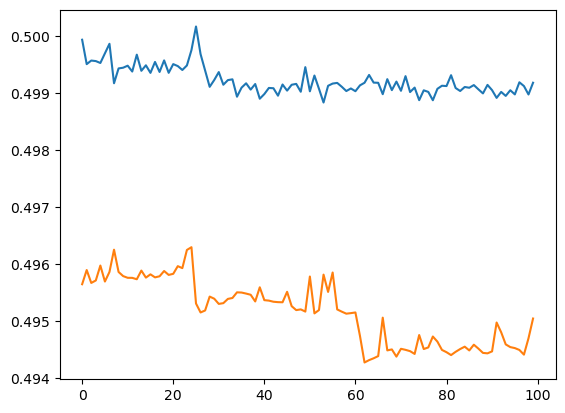

In [61]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

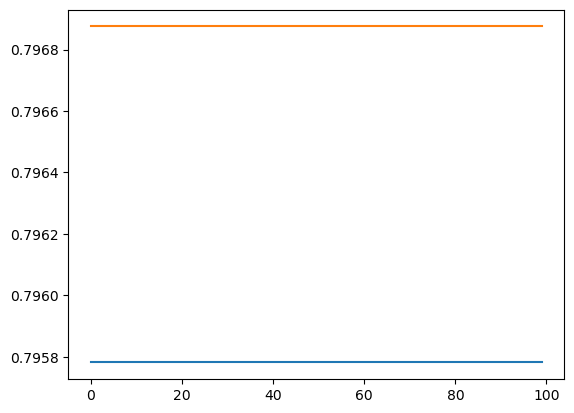

In [62]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])